In [1]:
import cmocean
import matplotlib.pyplot as plt
import xarray as xr
import warnings
from pathlib import Path

import pycompo.core.composite as pccompo
import pycompo.core.utils as pcutil
import pycompo.core.plot as pcplot
import pycompo.core.sigtest as pcsig

import hfplot.figure.figure as hffig
from hfplot.settings import STYLES

warnings.filterwarnings(action='ignore')

# read in configuration file
config_path = '/home/m/m300738/libs/pycompo/config'
config_files = {
    'ngc5004_opv4_w0': f"{config_path}/settings_ngc5004_opv4_w0.yaml",
    'ngc5004_opv4_w1': f"{config_path}/settings_ngc5004_opv4_w1.yaml",
    'ngc5004_opv4_w1_p': f"{config_path}/settings_ngc5004_opv4_w1_p.yaml",
}
config = {i: pcutil.read_yaml_config(c) for i, c in config_files.items()}
ana_times = {i: pcutil.create_analysis_times(c) for i, c in config.items()}

### Read in composites

In [2]:
rb_compo, rb_sigmask, rb_popmeans, rb_compo_corrected = {}, {}, {}, {}

for i, c in config.items():
    # read in composite data
    inpath = Path(f"{c['data']['outpath']}/{i}/")
    infile_compo = Path(f"{i}_composite_rainbelt.nc")
    rb_compo[i] = xr.open_dataset(str(inpath/infile_compo))
    rb_compo[i] = pccompo.adjust_units(rb_compo[i], rb_compo[i].data_vars)

    # read in p-values and calculate field significance
    try:
        infile_pvalue = Path(f"{i}_pvalue_rainbelt.nc")
        rb_pvalue = xr.open_dataset(str(inpath/infile_pvalue))
        rb_sigmask[i] = pcsig.get_field_significance(rb_pvalue, alpha_FDR=0.1)
    except:
        pass

    # Correct composites by population means
    rb_popmeans[i] = []
    ipath_popms = Path(f"{c['data']['outpath']}/{i}/popmeans/")
    for start_time, end_time in zip(ana_times[i], ana_times[i][1:]):
        fdate_str = pcutil.create_ftime_str(start_time, end_time)
        ifile = Path(f"{i}_popmeans_rainbelt_{fdate_str}.nc")
        rb_popmeans[i].append(
            xr.open_dataset(ipath_popms/ifile).mean(dim='time').compute()
            )
        
    rb_popmeans[i] = xr.concat(rb_popmeans[i], dim='time').mean(dim="time")
    rb_popmeans[i] = pccompo.adjust_units(rb_popmeans[i], rb_popmeans[i].data_vars)

    rb_compo_corrected[i] = rb_compo[i] - rb_popmeans[i]

### Plotting

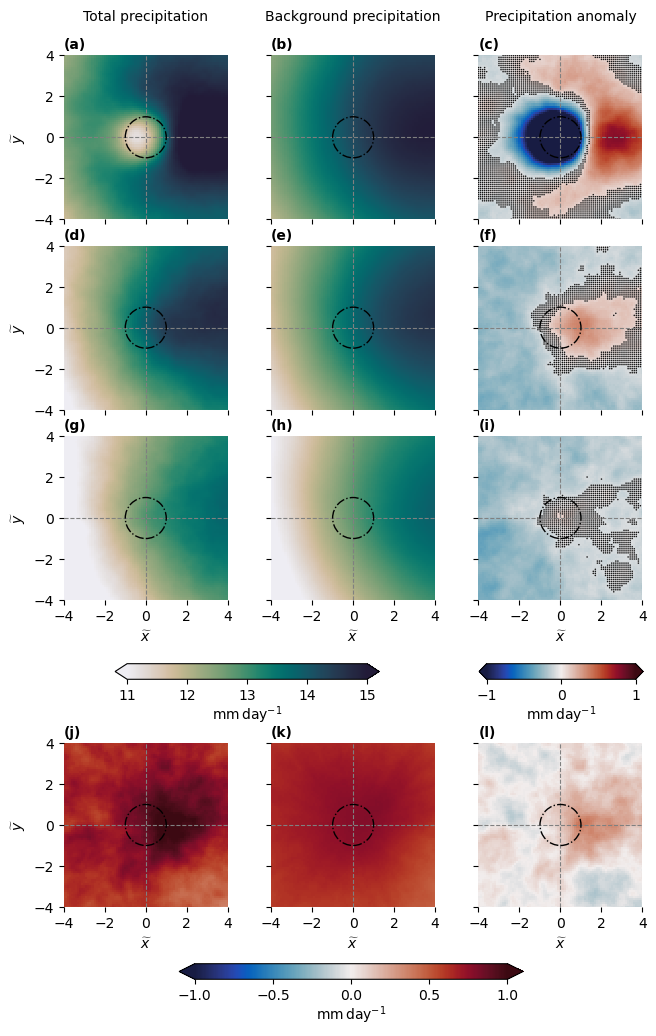

In [6]:
compo_data_bg = rb_compo
compo_data_ano = rb_compo_corrected
compo_data_bg['ngc5004_opv4_w1_diff'] = \
    compo_data_bg['ngc5004_opv4_w1'] - compo_data_bg['ngc5004_opv4_w1_p']

compo_data_ano['ngc5004_opv4_w1_diff'] = \
    compo_data_ano['ngc5004_opv4_w1'] - compo_data_ano['ngc5004_opv4_w1_p']
sigmask = rb_sigmask

CRANGE = {
    'pr_total': [11, 15],
    'pr_ano': [-1.0, 1.0],
    'pr_bg': [11, 15],
}
TITLE = {
    'pr_total': "$P$",
    'pr_ano': "$P'$",
    'pr_bg': "$\overline{P}$",
}
TITLE = {
    'pr_total': 'Total precipitation',
    'pr_ano': 'Precipitation anomaly',
    'pr_bg': 'Background precipitation',
}
CLABEL = 'mm$\,$day$^{-1}$'

fig = plt.figure(figsize=(8, 12))
gs = fig.add_gridspec(
    6, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1, 1, 0.55, 1, 0.28],
    wspace=0.01, hspace=0.2,
    )
axes = [None] * 12

axes[0] = fig.add_subplot(gs[0, 0])
axes[1] = fig.add_subplot(gs[0, 1], sharex=axes[0], sharey=axes[0])
axes[2] = fig.add_subplot(gs[0, 2], sharex=axes[0], sharey=axes[0])

axes[3] = fig.add_subplot(gs[1, 0], sharex=axes[0], sharey=axes[0])
axes[4] = fig.add_subplot(gs[1, 1], sharex=axes[0], sharey=axes[0])
axes[5] = fig.add_subplot(gs[1, 2], sharex=axes[0], sharey=axes[0])

axes[6] = fig.add_subplot(gs[2, 0], sharex=axes[0], sharey=axes[0])
axes[7] = fig.add_subplot(gs[2, 1], sharex=axes[0], sharey=axes[0])
axes[8] = fig.add_subplot(gs[2, 2], sharex=axes[0], sharey=axes[0])

axes[9] = fig.add_subplot(gs[4, 0], sharex=axes[0], sharey=axes[0])
axes[10] = fig.add_subplot(gs[4, 1], sharex=axes[0], sharey=axes[0])
axes[11] = fig.add_subplot(gs[4, 2], sharex=axes[0], sharey=axes[0])

cbar1 = fig.add_subplot(gs[3, :])
cbar2 = fig.add_subplot(gs[5, :])
cbar1.set_visible(False)
cbar2.set_visible(False)

# Plotting
for i, exp in enumerate(compo_data_ano.keys()):
    var = 'pr_total'
    if exp != 'ngc5004_opv4_w1_diff':
        pl1 = axes[i*3].pcolormesh(
            compo_data_bg[exp]['pr_bg']['En_rota2_featcen_x'],
            compo_data_bg[exp]['pr_bg']['En_rota2_featcen_y'],
            (compo_data_bg[exp]['pr_bg'] + compo_data_ano[exp]['pr_ano']).transpose(),
            vmin=CRANGE[var][0], vmax=CRANGE[var][1], cmap=cmocean.cm.rain,
            )
    else:
        pl1 = axes[i*3].pcolormesh(
            compo_data_bg[exp]['pr_bg']['En_rota2_featcen_x'],
            compo_data_bg[exp]['pr_bg']['En_rota2_featcen_y'],
            (compo_data_bg[exp]['pr_bg'] + compo_data_ano[exp]['pr_ano']).transpose(),
            vmin=-1.2, vmax=1.2, cmap=cmocean.cm.balance,
            )
    if i == 0:
        axes[i*3].set_title(TITLE[var], pad=25, fontsize=10)

    # Precipitation anomaly warm patches
    var = 'pr_bg'
    if exp != 'ngc5004_opv4_w1_diff':
        pl2 = axes[i*3 + 1].pcolormesh(
            compo_data_bg[exp][var]['En_rota2_featcen_x'],
            compo_data_bg[exp][var]['En_rota2_featcen_y'],
            compo_data_bg[exp][var].transpose(),
            vmin=CRANGE[var][0], vmax=CRANGE[var][1], cmap=cmocean.cm.rain, 
        )
    else:
        pl2 = axes[i*3 + 1].pcolormesh(
            compo_data_bg[exp][var]['En_rota2_featcen_x'],
            compo_data_bg[exp][var]['En_rota2_featcen_y'],
            compo_data_bg[exp][var].transpose(),
            vmin=-1.2, vmax=1.2, cmap=cmocean.cm.balance,
        )
    if i == 0:
        axes[i*3 + 1].set_title(TITLE[var], pad=25, fontsize=10)

    # Precipitation anomaly warm patches
    var = 'pr_ano'
    pl3 = axes[i*3 + 2].pcolormesh(
        compo_data_ano[exp][var]['En_rota2_featcen_x'],
        compo_data_ano[exp][var]['En_rota2_featcen_y'],
        compo_data_ano[exp][var].transpose(),
        vmin=CRANGE[var][0], vmax=CRANGE[var][1],cmap=cmocean.cm.balance,
    )
    if exp != 'ngc5004_opv4_w1_diff':
        pcplot.plot_sigmask(axes[i*3 + 2], sigmask[exp]['pr_ano'])
    if i == 0:
        axes[i*3 + 2].set_title(TITLE[var], pad=25, fontsize=10)

    if i == 2:
        var = "pr_bg"
        ticks = [11, 12, 13, 14, 15]
        ax = fig.add_axes([0.215, 0.36, 0.33, 0.013])
        cbar = fig.colorbar(
            pl2, cax=ax, ticks=ticks, orientation='horizontal', extend='both',
            )
        cbar.set_label(label=CLABEL, labelpad=1)

        var = "pr_ano"
        ticks = [-1, 0, 1]
        ax = fig.add_axes([0.67, 0.36, 0.205, 0.013])
        cbar = fig.colorbar(
            pl3, cax=ax, ticks=ticks, orientation='horizontal', extend='both',
            )
        cbar.set_label(label=CLABEL, labelpad=1)

    if i == 3:
        ticks = [-1, -0.5, 0, 0.5, 1]
        ax = fig.add_axes([0.295, 0.11, 0.43, 0.013])
        cbar = fig.colorbar(
            pl3, cax=ax, ticks=ticks, orientation='horizontal', extend='both',
            )
        cbar.set_label(label=CLABEL, labelpad=1)


# Make plot nice
for i in range(12):
    pcplot.plot_feature_grid(
        axes[i],
        compo_data_ano[exp]['En_rota2_featcen_x'],
        compo_data_ano[exp]['En_rota2_featcen_y'],
        )
    pcplot.plot_feature_circle(axes[i], (0, 0), 1, lw=1)
    axes[i].set_aspect('equal')

axes[0].set_xlim(-4, 4)
axes[0].set_ylim(-4, 4)
for ax in axes:
    ax.tick_params(labelbottom=False, labelleft=False)
for i in [6, 7, 8, 9, 10, 11]:
    axes[i].tick_params(labelbottom=True)
    axes[i].set_xlabel('$\\widetilde{x}$')
    axes[i].set_xticks([-4, -2, 0, 2, 4])
for i in [0, 3, 6, 9]:
    axes[i].tick_params(labelleft=True)
    axes[i].set_ylabel('$\\widetilde{y}$')
    axes[i].set_yticks([-4, -2, 0, 2, 4])

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(False)

# Subfigure labels
xpos = 0.0
ypos = 1.02
labels = [
    '(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)',
    '(k)', '(l)',
    ]
for i, label in enumerate(labels):
    axes[i].text(
        xpos, ypos, label,
        transform=axes[i].transAxes, fontweight="bold", ha='left', va='bottom',
        )

# Save plot
plt.tight_layout()
outpath = Path(f'/home/m/m300738/project_TRR181L4/plots/paper/')
outpath.mkdir(parents=True, exist_ok=True)
outfile = Path('figure03.png')
plt.savefig(str(outpath/outfile), dpi=600, bbox_inches='tight')
plt.show()